# **🌍 Global Suicide Rate Prediction with ML**

**What this notebook does (step by step):**
1. Load the WHO + World Bank dataset and take a first look
2. Clean the data (missing values) and explore it with charts (EDA)
3. Create simple new features
4. Train models from a **baseline** (Linear Regression) up to **Random Forest & Gradient Boosting**
5. Compare all models and pick the best one
6. Check feature importance and write a conclusion

**Goal:** predict `suicide_rate_per_100k` (a regression problem) from country, year, sex, age group, GDP and population.

> ℹ️ This is a statistical/public-health dataset. The aim is learning ML and understanding population-level patterns, not judging individuals.

## **1. Import Libraries**

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

## **2. Load the Data**

In [2]:
import os
FILE = "/kaggle/input/datasets/samartalwar/global-suicide-rates-and-socioeconomic-indicators/global_suicide_rates_real_who_worldbank.csv"
# On Kaggle the file sits inside /kaggle/input/<dataset-name>/ - find it automatically
for root, _, files in os.walk("/kaggle/input"):
    if FILE in files: FILE = os.path.join(root, FILE)

df = pd.read_csv(FILE)
print("Shape:", df.shape)
df.head()

Shape: (18315, 10)


,country,country_code,year,sex,age_bracket,suicide_rate_per_100k,generation,gdp_usd,gdp_per_capita_usd,total_country_population
0,Afghanistan,AFG,2000,both,all_ages,4.36,All Cohorts,3.521418e+09,174.930991,20130327.0
1,Afghanistan,AFG,2000,female,all_ages,2.91,All Cohorts,3.521418e+09,174.930991,20130327.0
2,Afghanistan,AFG,2000,male,all_ages,5.79,All Cohorts,3.521418e+09,174.930991,20130327.0
3,Afghanistan,AFG,2001,both,all_ages,4.38,All Cohorts,2.813572e+09,138.706822,20284307.0
4,Afghanistan,AFG,2001,female,all_ages,2.92,All Cohorts,2.813572e+09,138.706822,20284307.0


In [3]:
df.info()
print("\nMissing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nAge groups:", df["age_bracket"].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18315 entries, 0 to 18314
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   18315 non-null  object 
 1   country_code              18315 non-null  object 
 2   year                      18315 non-null  int64  
 3   sex                       18315 non-null  object 
 4   age_bracket               18315 non-null  object 
 5   suicide_rate_per_100k     18315 non-null  float64
 6   generation                18315 non-null  object 
 7   gdp_usd                   18000 non-null  float64
 8   gdp_per_capita_usd        18000 non-null  float64
 9   total_country_population  18315 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 1.4+ MB

Missing values:
 gdp_usd               315
gdp_per_capita_usd    315
dtype: int64

Age groups: ['all_ages' '10-19' '15-19' '15-29' '20-29' '30-39' '30-49' '40-49'
 '50-

**Observations**
- ~18K rows, 185 countries, years 2000-2021.
- `gdp_usd` and `gdp_per_capita_usd` have some missing values.
- `generation` has only one value ("All Cohorts") so it adds no information → we drop it.
- `country_code` repeats `country` → we drop it.
- Detailed age groups exist only for 2021; other years have `all_ages`.

## **3. Data Cleaning**

In [4]:
df = df.drop(columns=["generation", "country_code"])
# GDP columns are very skewed -> use log scale (makes patterns easier for models)
df["log_gdp_pc"] = np.log1p(df["gdp_per_capita_usd"])
df["log_pop"] = np.log1p(df["total_country_population"])
df = df.drop(columns=["gdp_usd", "gdp_per_capita_usd", "total_country_population"])
print("Duplicates:", df.duplicated().sum())
df.head(3)

Duplicates: 0


,country,year,sex,age_bracket,suicide_rate_per_100k,log_gdp_pc,log_pop
0,Afghanistan,2000,both,all_ages,4.36,5.170092,16.817738
1,Afghanistan,2000,female,all_ages,2.91,5.170092,16.817738
2,Afghanistan,2000,male,all_ages,5.79,5.170092,16.817738


## **4. Exploratory Data Analysis (EDA)**

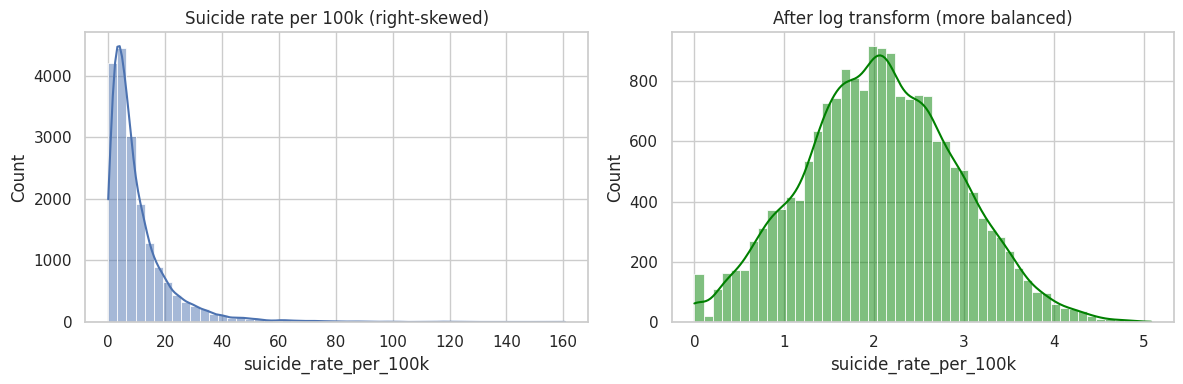

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["suicide_rate_per_100k"], bins=50, kde=True, ax=ax[0])
ax[0].set_title("Suicide rate per 100k (right-skewed)")
sns.histplot(np.log1p(df["suicide_rate_per_100k"]), bins=50, kde=True, ax=ax[1], color="green")
ax[1].set_title("After log transform (more balanced)")
plt.tight_layout(); plt.show()

The target is **right-skewed**, so later we train models on the log of the target - this usually helps.

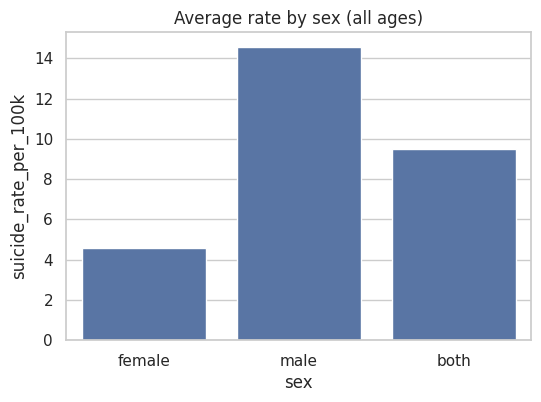

In [6]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df[df.age_bracket == "all_ages"], x="sex", y="suicide_rate_per_100k",
            order=["female", "male", "both"], errorbar=None)
plt.title("Average rate by sex (all ages)"); plt.show()

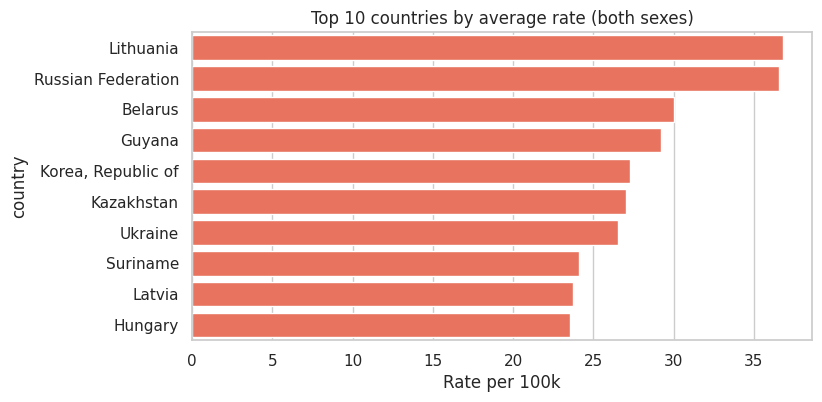

In [7]:
top = (df[(df.age_bracket == "all_ages") & (df.sex == "both")]
       .groupby("country")["suicide_rate_per_100k"].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(8, 4)); sns.barplot(x=top.values, y=top.index, color="tomato")
plt.title("Top 10 countries by average rate (both sexes)"); plt.xlabel("Rate per 100k"); plt.show()

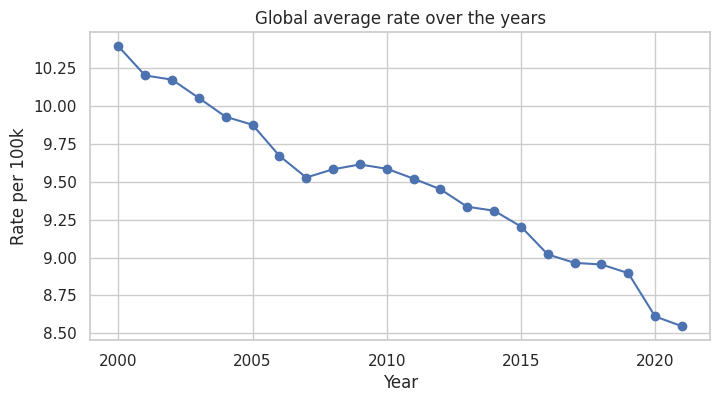

In [8]:
trend = df[(df.age_bracket == "all_ages") & (df.sex == "both")].groupby("year")["suicide_rate_per_100k"].mean()
plt.figure(figsize=(8, 4)); plt.plot(trend.index, trend.values, marker="o")
plt.title("Global average rate over the years"); plt.xlabel("Year"); plt.ylabel("Rate per 100k"); plt.show()

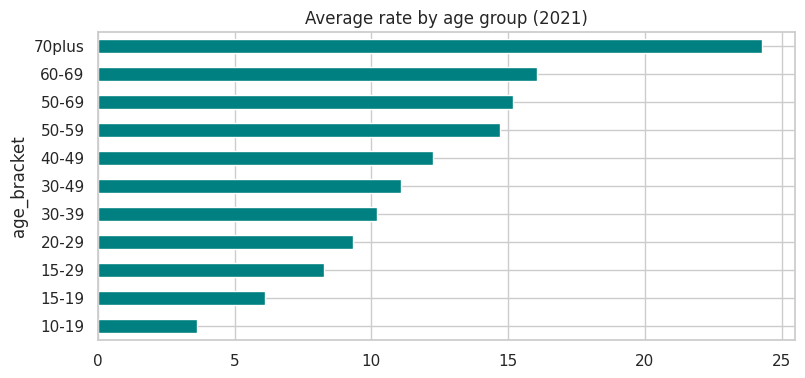

In [9]:
age = df[(df.age_bracket != "all_ages") & (df.sex == "both")].groupby("age_bracket")["suicide_rate_per_100k"].mean()
plt.figure(figsize=(9, 4)); age.sort_values().plot(kind="barh", color="teal")
plt.title("Average rate by age group (2021)"); plt.show()

**EDA takeaways**
- **Males** have a much higher rate than females.
- Rates differ a lot **between countries**, so country is an important feature.
- Older age groups tend to show higher rates.

## **5. Feature Engineering**
We add a few simple columns that help models understand the data:
- `age_mid`: middle of the age group (e.g. "20-29" → 24.5)
- `is_all`: 1 if the row covers all ages
- `span`: width of the age group
- `country_mean`, `country_sex_mean`: a country's typical rate (calculated **only from the training data** to avoid cheating)

In [10]:
def age_mid(a):
    if a == "all_ages": return np.nan
    if a == "70plus": return 75
    lo, hi = a.split("-"); return (int(lo) + int(hi)) / 2

df["age_mid"] = df["age_bracket"].map(age_mid)
df["is_all"] = (df["age_bracket"] == "all_ages").astype(int)
df["span"] = df["age_bracket"].map(lambda a: 0 if a in ("all_ages", "70plus")
                                   else int(a.split("-")[1]) - int(a.split("-")[0]))
df["sex_code"] = df["sex"].map({"both": 0, "female": 1, "male": 2})
df.head(3)

,country,year,sex,age_bracket,suicide_rate_per_100k,log_gdp_pc,log_pop,age_mid,is_all,span,sex_code
0,Afghanistan,2000,both,all_ages,4.36,5.170092,16.817738,NaN,1,0,0
1,Afghanistan,2000,female,all_ages,2.91,5.170092,16.817738,NaN,1,0,1
2,Afghanistan,2000,male,all_ages,5.79,5.170092,16.817738,NaN,1,0,2


## **6. Train / Test Split**
We keep 80% for training and 20% for testing (unseen data to judge the models fairly).

In [11]:
y = df["suicide_rate_per_100k"]
X = df.drop(columns="suicide_rate_per_100k")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X["age_bracket"] + X["sex"])

# Country averages from TRAINING rows only (all-ages rows)
tr = X_train.join(y_train); tr = tr[tr.is_all == 1]
country_sex = tr.groupby(["country", "sex"])["suicide_rate_per_100k"].mean().rename("country_sex_mean")
country_all = tr.groupby("country")["suicide_rate_per_100k"].mean().rename("country_mean")

def add_country_stats(d):
    return d.join(country_sex, on=["country", "sex"]).join(country_all, on="country").drop(columns="country")

X_train, X_test = add_country_stats(X_train), add_country_stats(X_test)
print(X_train.shape, X_test.shape)

(14652, 11) (3663, 11)


## **7. Preprocessing**
Text columns → one-hot encoding, numeric columns → fill missing values with the median (and scale for linear models).

In [12]:
cat_cols = ["sex", "age_bracket"]
num_cols = ["year", "log_gdp_pc", "log_pop", "sex_code", "age_mid", "is_all", "span",
            "country_sex_mean", "country_mean"]

def make_pre(scale=False):
    steps = [("imp", SimpleImputer(strategy="median"))] + ([("sc", StandardScaler())] if scale else [])
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", Pipeline(steps), num_cols)])

## **8. Train Multiple Models (Baseline → Best)**
| Model | Role |
|---|---|
| Linear Regression | Simple **baseline** |
| Decision Tree | Single tree, easy to understand |
| Random Forest | Many trees averaged (strong) |
| Hist Gradient Boosting | Trees that fix each other's errors (strong) |

For the tree models we train on `log(1 + rate)` and convert predictions back - this handles the skewed target.

In [13]:
def log_wrap(model):
    return TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1)

models = {
    "Linear Regression (baseline)": Pipeline([("pre", make_pre(True)), ("m", LinearRegression())]),
    "Decision Tree": Pipeline([("pre", make_pre()), ("m", log_wrap(DecisionTreeRegressor(max_depth=12, random_state=42)))]),
    "Random Forest": Pipeline([("pre", make_pre()), ("m", log_wrap(RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)))]),
    "Hist Gradient Boosting": Pipeline([("pre", make_pre()), ("m", HistGradientBoostingRegressor(learning_rate=0.05, max_iter=400, random_state=42))]),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_test), 0, None)   # rates cannot be negative
    rows.append({"Model": name,
                 "R2": r2_score(y_test, pred),
                 "MAE": mean_absolute_error(y_test, pred),
                 "RMSE": mean_squared_error(y_test, pred) ** 0.5})

results = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
results.round(3)

,Model,R2,MAE,RMSE
0,Random Forest,0.928,1.253,3.136
1,Hist Gradient Boosting,0.921,1.451,3.272
2,Decision Tree,0.879,1.830,4.056
3,Linear Regression (baseline),0.672,3.200,6.677


## **9. Compare the Models**

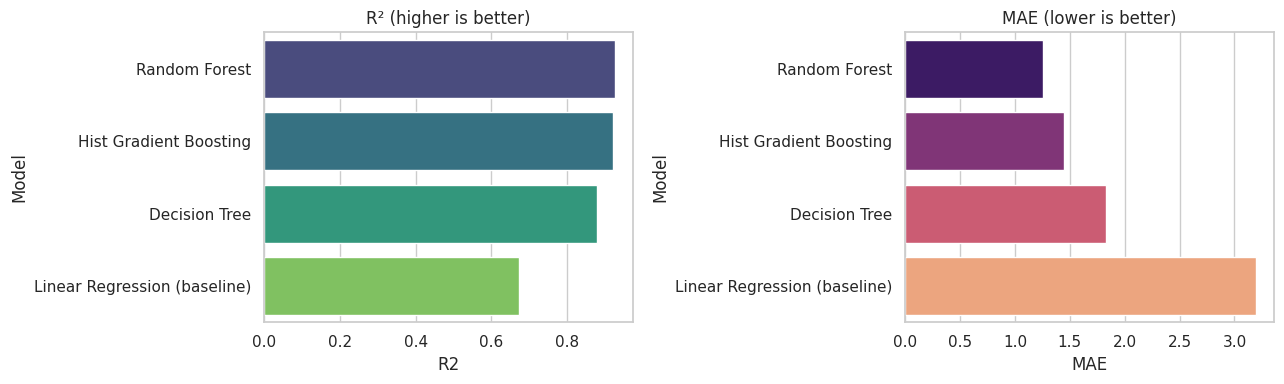

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=results, y="Model", x="R2", ax=ax[0], palette="viridis"); ax[0].set_title("R² (higher is better)")
sns.barplot(data=results, y="Model", x="MAE", ax=ax[1], palette="magma"); ax[1].set_title("MAE (lower is better)")
plt.tight_layout(); plt.show()

## **10. Improve the Best Model (Light Tuning)**
A small grid search on Random Forest, using 3-fold cross-validation.

In [15]:
from sklearn.model_selection import GridSearchCV

rf = Pipeline([("pre", make_pre()), ("m", log_wrap(RandomForestRegressor(n_jobs=-1, random_state=42)))])
grid = {"m__regressor__n_estimators": [200, 400],
        "m__regressor__min_samples_leaf": [1, 2],
        "m__regressor__max_features": [0.5, 1.0]}
search = GridSearchCV(rf, grid, cv=3, scoring="r2", n_jobs=-1).fit(X_train, y_train)
best = search.best_estimator_
print("Best params:", search.best_params_)

pred = np.clip(best.predict(X_test), 0, None)
print(f"Tuned RF -> R2: {r2_score(y_test, pred):.3f} | MAE: {mean_absolute_error(y_test, pred):.2f} | RMSE: {mean_squared_error(y_test, pred)**0.5:.2f}")

Best params: {'m__regressor__max_features': 1.0, 'm__regressor__min_samples_leaf': 1, 'm__regressor__n_estimators': 400}
Tuned RF -> R2: 0.928 | MAE: 1.25 | RMSE: 3.13


## **11. Actual vs Predicted**

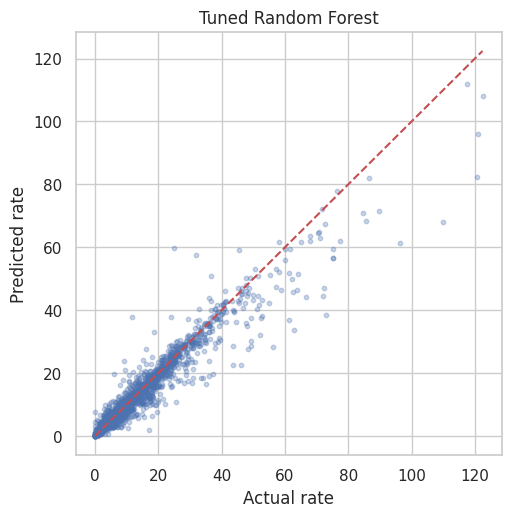

In [16]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, pred, alpha=0.3, s=10)
lim = [0, y_test.max()]; plt.plot(lim, lim, "r--")
plt.xlabel("Actual rate"); plt.ylabel("Predicted rate"); plt.title("Tuned Random Forest"); plt.show()

Points close to the red line mean good predictions.

## **12. Feature Importance**
Which columns does the model rely on most?

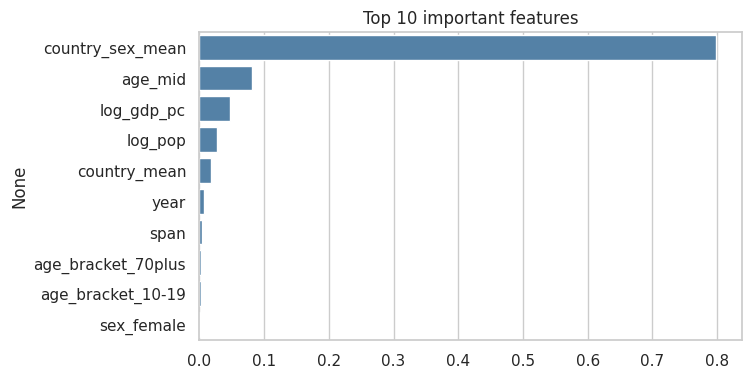

In [17]:
names = best.named_steps["pre"].get_feature_names_out()
imp = best.named_steps["m"].regressor_.feature_importances_
imp = pd.Series(imp, index=[n.split("__")[1] for n in names]).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 4)); sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.title("Top 10 important features"); plt.show()

## **13. Conclusion**

In [18]:
final = pd.concat([results, pd.DataFrame([{"Model": "Random Forest (tuned)",
        "R2": r2_score(y_test, pred), "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5}])]).sort_values("R2", ascending=False)
final.reset_index(drop=True).round(3)

,Model,R2,MAE,RMSE
0,Random Forest (tuned),0.928,1.251,3.125
1,Random Forest,0.928,1.253,3.136
2,Hist Gradient Boosting,0.921,1.451,3.272
3,Decision Tree,0.879,1.830,4.056
4,Linear Regression (baseline),0.672,3.200,6.677


### **Summary**
- **Data:** WHO suicide rates joined with World Bank GDP and population for 185 countries (2000-2021).
- **Patterns found:** male rates are far higher than female rates, countries differ strongly, and older age groups tend to show higher rates.
- **Models:** Linear Regression was a weak baseline because the relationships are not straight lines. Tree-based models (Random Forest, Gradient Boosting) scored much higher, with **Random Forest (tuned, log target)** among the best with an **R² of about 0.93** on unseen test rows.
- **Key drivers:** a country's typical rate, sex, age group and year matter most; GDP and population add smaller signals.

### **Limitations**
- Rows from the same country appear in both train and test, so the model learns each country's typical level. It will be **less accurate for a completely new country**.
- Detailed age groups exist only for 2021.
- Reported rates depend on each country's data quality.

### **Next steps**
Try time-based validation, add more indicators (unemployment, health spending), and test XGBoost / LightGBM.

*If this helped, please upvote the notebook!* 👍